In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset,random_split
from torchvision import models,transforms,datasets


In [ ]:
import matplotlib.pyplot as plt
import numpy


In [ ]:
import time

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.1 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Change to your specific folder path in Google Drive
folder_path = '/content/drive/MyDrive/dataset'

# Check if the folder exists
if os.path.exists(folder_path):
    print(f"Contents of '{folder_path}':")
    !ls "{folder_path}"
else:
    print(f"Folder '{folder_path}' does not exist. Please check the path.")


Contents of '/content/drive/MyDrive/dataset':
F_Breakage  F_Crushed  F_Normal  R_Breakage  R_Crushed	R_Normal


In [ ]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Load Data

In [ ]:
custom_transform= transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])]
)

In [ ]:
dataset= datasets.ImageFolder(folder_path,custom_transform)

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [ ]:
class_names = dataset.classes

In [ ]:
dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
len(dataset)

2300

In [ ]:
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [ ]:
train_size= int(0.8*len(dataset))
test_size= len(dataset)-train_size

In [ ]:
train_size,test_size

(1840, 460)

In [ ]:
train_dataset, test_dataset= random_split(dataset, [train_size,test_size])

In [ ]:
len(train_dataset), len(test_dataset)

(1840, 460)

In [ ]:
train_dataloader= DataLoader(train_dataset,batch_size=32, shuffle=True, pin_memory=True)
test_dataloader= DataLoader(test_dataset,batch_size=32, shuffle=False, pin_memory=True)

In [ ]:
for images, labels in train_dataloader:
    print(images.shape)
    print(labels.shape)
    break


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
images[1].shape

torch.Size([3, 224, 224])

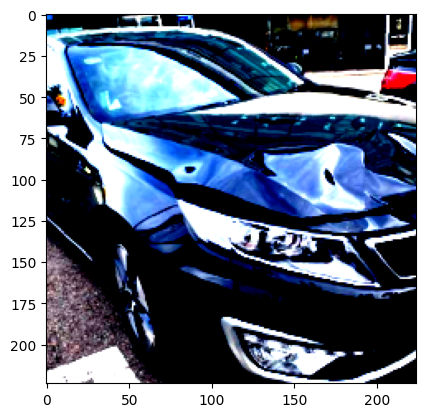

In [ ]:
plt.imshow(images[8].permute(1,2,0))
plt.show()

### CNN Model

In [ ]:
class CNNModel(nn.Module):
  def __init__(self,input_channels):
    super().__init__()
    self.features= nn.Sequential(
        nn.Conv2d(input_channels,32,kernel_size=3,stride=1,padding=1), #32,224,224
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2), #32,112,112

        nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1), #64,112,112
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2), #64,56,56

        nn.Conv2d(64,16,kernel_size=3,stride=1,padding=1), #16,56,56
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),#16,28,28
    )

    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(16*28*28,512),
        nn.ReLU(),
        nn.Linear(512,6)
    )

  def forward(self,features):
    return self.classifier(self.features(features))


In [ ]:
car_model= CNNModel(3)

In [ ]:
car_model

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=6, bias=True)
  )
)

In [ ]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_dataloader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in test_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds")

    return all_labels, all_predictions

In [ ]:
criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(car_model.parameters(),lr= 0.1)
epochs=1

In [ ]:
train_model(car_model,criterion, optimizer, epochs)

Train_loss: 0.05691611021757126
Train_loss: 0.055789072066545486
Train_loss: 0.05840758979320526
Train_loss: 0.056955501437187195
Train_loss: 0.058068450540304184
Epoch [1/1], Avg Loss: 2.6826
OverAll Accuracy: 22.17
Execution time: 679.7210869789124 seconds


([np.int64(2),
  np.int64(4),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(3),
  np.int64(5),
  np.int64(2),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(5),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64

### Model-2: CNN+regularization

In [ ]:
class CNNModelRegularization(nn.Module):
  def __init__(self,input_channels):
    super().__init__()
    self.features= nn.Sequential(
        nn.Conv2d(input_channels,32,kernel_size=3,stride=1,padding=1), #32,224,224
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2), #32,112,112

        nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1), #64,112,112
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2), #64,56,56

        nn.Conv2d(64,16,kernel_size=3,stride=1,padding=1), #16,56,56
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),#16,28,28
    )

    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(16*28*28,512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512,6)
    )

  def forward(self,features):
    return self.classifier(self.features(features))


In [ ]:
criterion= nn.CrossEntropyLoss()
optimizer2= optim.Adam(car_model.parameters(),lr= 0.1,weight_decay=0.01)
epochs=1


In [ ]:
car_model2= CNNModelRegularization(3)

In [ ]:
labels2,predictions2= train_model(car_model2,criterion, optimizer, epochs)

### Model-3:

In [ ]:
model= models.efficientnet_b0(weights='DEFAULT')
model.classifier[1].in_features

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 181MB/s]


1280

In [ ]:
class CNNModelWithEfficientNet(nn.Module):
  def __init__(self,input_channels):
    super().__init__()
    self.model= models.efficientnet_b0(weights='DEFAULT')

    for param in self.model.parameters():
      param.requires_grad= False

    self.model.classifier= nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(self.model.classifier[1].in_features,6)
    )

  def forward(self,features):
    return self.model(features)



In [ ]:
efficientnet= CNNModelWithEfficientNet(3)
efficientnet= efficientnet.to(device)

In [ ]:
criterion= nn.CrossEntropyLoss()
optimizer3= optim.Adam(efficientnet.parameters(),lr= 0.1)
epochs=1

In [ ]:
labels3, predicted3= train_model(efficientnet,criterion, optimizer3,1)

Batch: 10, Epoch: 1, Loss: 5.20
Batch: 20, Epoch: 1, Loss: 6.12
Batch: 30, Epoch: 1, Loss: 2.58
Batch: 40, Epoch: 1, Loss: 5.49
Batch: 50, Epoch: 1, Loss: 3.50
Epoch [1/1], Avg Loss: 5.0147
*** Validation Accuracy: 65.22% ***
Execution time: 663.7516298294067 seconds


### Model-4: ResNet

In [ ]:
class ResNetModel(nn.Module):
  def __init__(self, input_channels):
    super().__init__()

    self.resnet= models.resnet50(weights='DEFAULT')

    for param in self.resnet.parameters():
      param.requires_grad= False

    # Unfreeze layer4 and fc layers
    for param in self.resnet.layer4.parameters():
        param.requires_grad = True

    self.resnet.fc= nn.Sequential(
        nn.Dropout2d(p=0.2),
        nn.Linear(self.resnet.fc.in_features,6)
    )


  def forward(self, features):
    return self.resnet(features)


In [ ]:
resnet_model= ResNetModel(3)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


In [ ]:
resnet_model

ResNetModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [ ]:
criterion= nn.CrossEntropyLoss()
optimizer4= optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=0.001)


In [ ]:
labels, predictions = train_model(resnet_model.to(device), criterion, optimizer4, epochs=10)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Batch: 10, Epoch: 1, Loss: 0.83
Batch: 20, Epoch: 1, Loss: 0.94
Batch: 30, Epoch: 1, Loss: 0.70
Batch: 40, Epoch: 1, Loss: 0.88
Batch: 50, Epoch: 1, Loss: 0.60
Epoch [1/10], Avg Loss: 0.8432
*** Validation Accuracy: 66.52% ***
Batch: 10, Epoch: 2, Loss: 0.27
Batch: 20, Epoch: 2, Loss: 0.38
Batch: 30, Epoch: 2, Loss: 0.37
Batch: 40, Epoch: 2, Loss: 0.41
Batch: 50, Epoch: 2, Loss: 0.38
Epoch [2/10], Avg Loss: 0.4300
*** Validation Accuracy: 76.74% ***
Batch: 10, Epoch: 3, Loss: 0.30
Batch: 20, Epoch: 3, Loss: 0.34
Batch: 30, Epoch: 3, Loss: 0.51
Batch: 40, Epoch: 3, Loss: 0.47
Batch: 50, Epoch: 3, Loss: 0.49
Epoch [3/10], Avg Loss: 0.3067
*** Validation Accuracy: 79.35% ***
Batch: 10, Epoch: 4, Loss: 0.43
Batch: 20, Epoch: 4, Loss: 0.21
Batch: 30, Epoch: 4, Loss: 0.13
Batch: 40, Epoch: 4, Loss: 0.16
Batch: 50, Epoch: 4, Loss: 0.26
Epoch [4/10], Avg Loss: 0.1848
*** Validation Accuracy: 78.48% ***
Batch: 10, Epoch: 5, Loss: 0.20
Batch: 20, Epoch: 5, Loss: 0.15
Batch: 30, Epoch: 5, Loss: 0

In [ ]:
num_classes= len(dataset.classes)


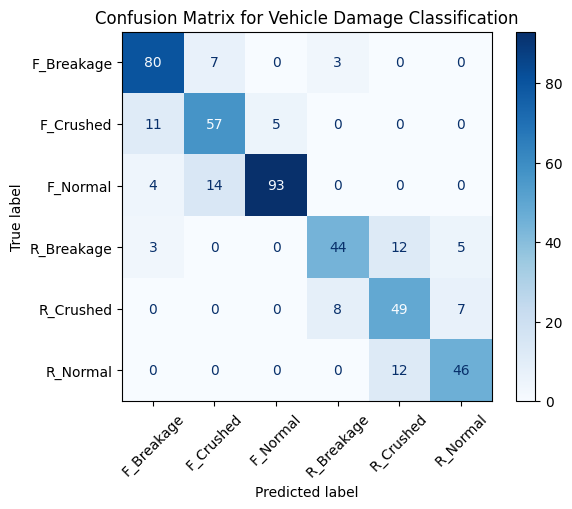

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
import pandas as pd
import numpy as np


conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [ ]:
torch.save(resnet_model.state_dict(), 'saved_model.pth')